In [1]:
%matplotlib widget
from epdfsuite import SAEDProcessor, extract_epdf

precession_angle = 0

## I.Create Sample Instance

In [2]:
datapath = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_II/'
sample_diff = datapath + "APH135b/Metro/diff/80X_Metro_200kV_1386.dm4" 

# File for geometric calibration, obtained from pyFAI calibration of a standard sample (LaB6)
poni_file = datapath + 'calib_metro.poni'

# Optional mask file, to exclude bad pixels or other artifacts from the analysis. Here we use a very large mask to simulate the presence of a beamstop, for test purposes.
mask = datapath + 'mask_test.edf' # very large mask, for test purpose and to simulate the presence of beamstop

# Optional MTF file, to correct for the modulation transfer function of the camera. This is obtained from a separate calibration using a slanted edge method.
mtf_file = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/mtf/metro_slanted.mtf'
sample = SAEDProcessor(sample_diff,
                     poni_file=poni_file,
                     #mask=mask,
                     mtf_file= mtf_file,
                     verbose=True,
                     precession_angle=precession_angle)




  ✓ camera type from database: Gatan 80X Metro
Loaded file: /home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_II/APH135b/Metro/diff/80X_Metro_200kV_1386.dm4
Sample information:
  binning: 1.0
  description: Gatan 80X Metro direct electron detector
  image_height: 2048
  image_width: 2048
  pixel_size: 5
  camera_type: Gatan 80X Metro
  camera_title: 80X_Metro_200kV_1386
  wavelength: 0.025079340450548007
  exposure_time: 128.00005974713713
[INFO] Pre-smoothing applied: sigma=0.5 px
[INFO] Loading image.
[INFO] Detecting center... [DONE]
[INFO] Estimating radius of a diffraction ring... [DONE]
[INFO] Refining center coordinates... [DONE]
[INFO] Collecting results.
----------------------------------------------------------
Center Detection (HoughTransform)     : (83.000, 69.000)
Center Refinement (IntensitySum)      : (83.800, 69.000)
Centre estimate from ediff (Hough): (x=335.20, y=276.00)


**Plot**

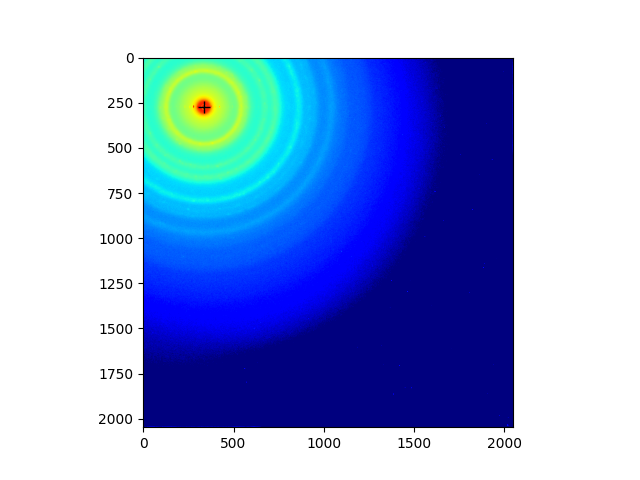

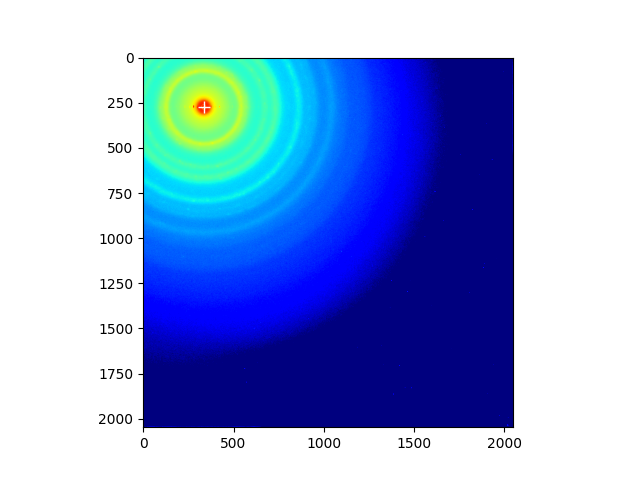

In [3]:

sample.plot(display_mask=True)

sample.plot(display_mask=False) # 

**Check image linearity**

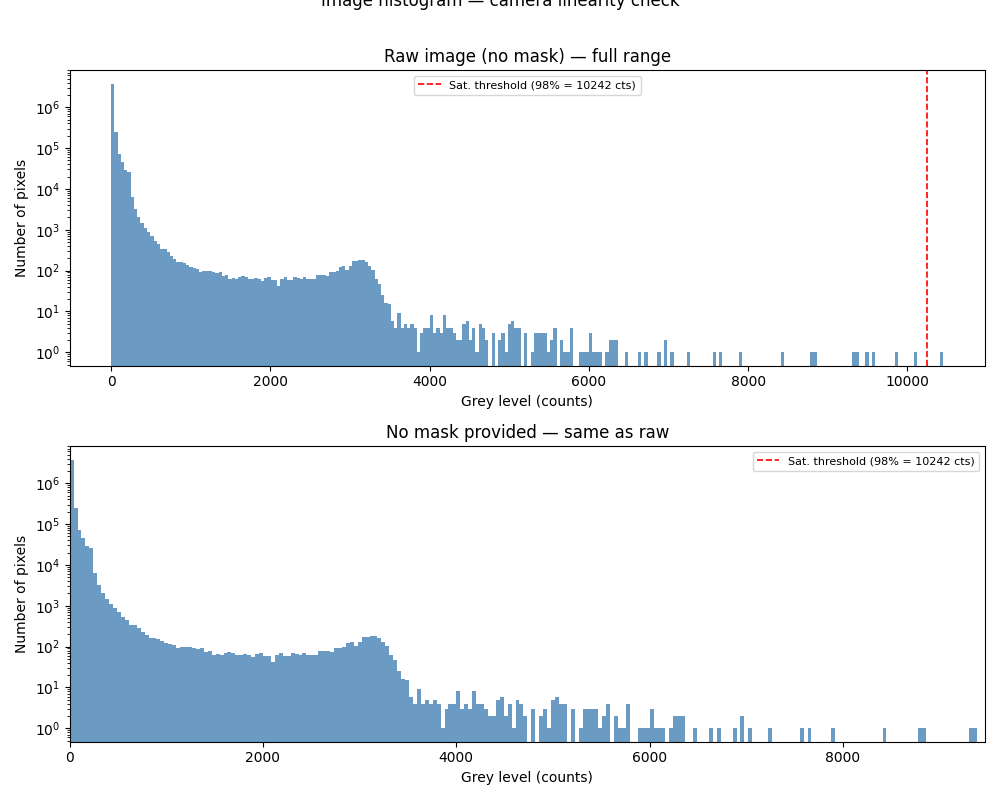

In [4]:
sample.inspect_histogram()

**Check centre determination**

[INFO] Loading image.
[INFO] Detecting center... [DONE]
[INFO] Estimating radius of a diffraction ring... [DONE]
[INFO] Refining center coordinates... [DONE]
[INFO] Collecting results.
----------------------------------------------------------
Center Detection (HoughTransform)     : (83.000, 69.000)
Center Refinement (IntensitySum)      : (83.800, 69.000)


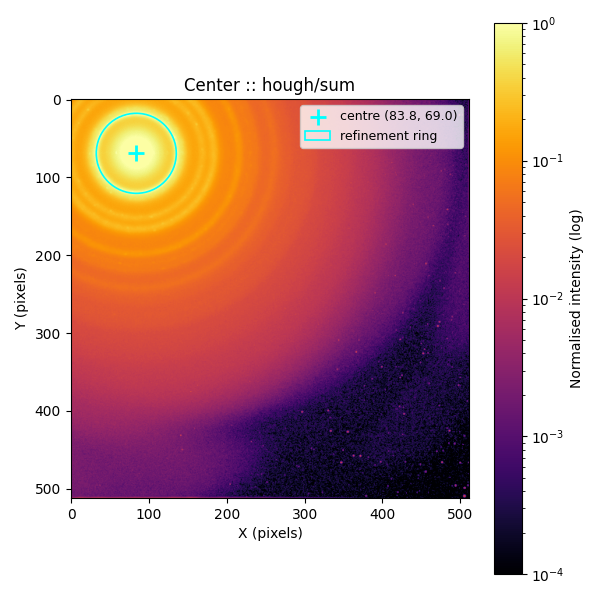

In [4]:
sample.plot_recalibrated_image()

**Integration**

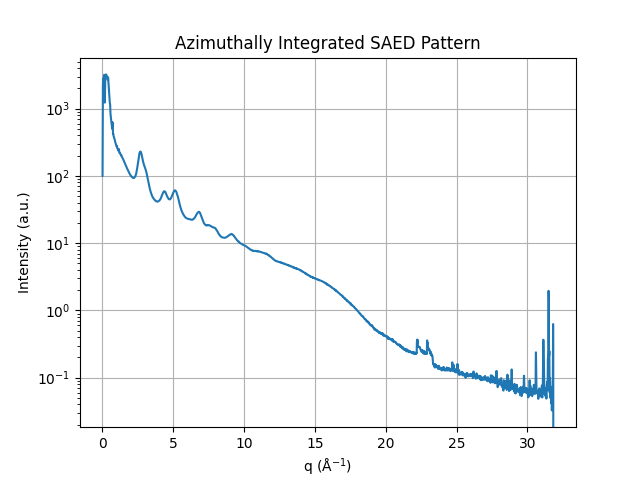

In [5]:
q,i=sample.integrate(plot=True)
import matplotlib.pyplot as plt


## II.Create Ref instance

In [6]:
ref_diff = datapath+ 'ref/80X_Metro_200kV_1383_Cfilm.dm4' # amorphous C grid diffraction data

ref = SAEDProcessor(ref_diff,
                     poni_file=poni_file,
                     mask=mask,
                     mtf_file= mtf_file,
                     verbose=False,
                     precession_angle=precession_angle,
                     amorphous=True)
# the beam center is computed using recalibrate_from_isocurves method, which is more robust for amorphous samples
# this is automatically done when the amorphous=True option is used, but can also be done manually using the recalibrate_from_isocurves method.

  ✓ camera type from database: Gatan 80X Metro
[INFO] Pre-smoothing applied: sigma=0.5 px
Centre estimate from iso-intensity contours: (x=321.88, y=255.50)


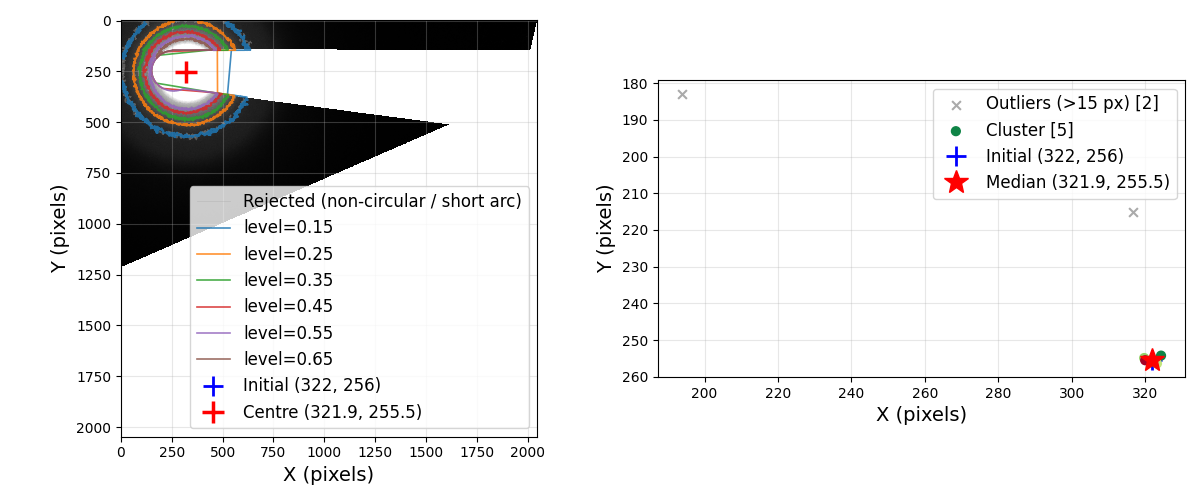

In [7]:
ref.plot_recalibrated_image()

## III. Extract ePDF using standalone function ***extract_epdf***

This function needs the following args:
- sample SAEDProcessor instance
- ref SAEDProcessor instance
- composition
- rmin, rmax, rstep: parameters to define r grid on which the PDF is extracted
- interactive: bool parameter for interactive PDF extraction 

        interactive = True: allows the user to determine manually bgscale, qmin, qmax, qmaxinst and rpoly parameters for PDF extraction

        interactive = False: bgscale, qmin, qmax, qmaxinst and rpoly parameters for PDF extraction can be passed as args to extract_epdf method.

In [ ]:
results = extract_epdf(
    sample, 
    ref,
    composition = 'Au',
    rmin=0.0,
    rmax=50.0,
    rstep=0.01,
    interactive = True)

Slide cursors to ajdust parameters values. Click "Save" to export results.


PDF saved to ./pdf_results.gr


Text(0, 0.5, 'G(r)')

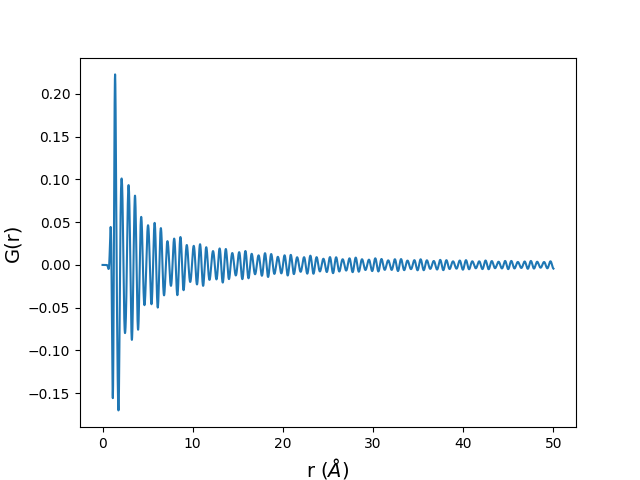

In [10]:
r,g=results.r, results.g
import matplotlib.pyplot as plt
plt.figure()
plt.plot(r,g)
plt.xlabel('r ($\AA$)',fontsize=14)
plt.ylabel('G(r)',fontsize=14)
